In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import pypyodbc
from sqlalchemy.engine import URL
import datetime

SERVER_NAME=''
DATABASE_NAME=''
USERNAME=""
PASSWORD=""
#(THESE ARE REMOVED FOR SECURITY PURPOSE)
connection_string = f"""
    DRIVER={{SQL Server}};
    SERVER={SERVER_NAME};
    DATABASE={DATABASE_NAME};
    UID={USERNAME};
    PWD={PASSWORD};
    Trusted_Connection=no;
"""

connection_url = URL.create('mssql+pyodbc', query={'odbc_connect': connection_string})
engine = create_engine(connection_url, module=pypyodbc)
print('Connection successfully created')


<>:7: SyntaxWarning: invalid escape sequence '\M'
<>:7: SyntaxWarning: invalid escape sequence '\M'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_27904\681299242.py:7: SyntaxWarning: invalid escape sequence '\M'
  SERVER_NAME='TBS25\MSSQLSERVER01'


Connection successfully created


In [252]:
sql=pd.read_sql_query('''
select FORMAT(CONVERT(DATETIME,OD.CreatedDate),'yyyy-MM-dd') as 'CreatedDate',sum(finalPrice) as Sales from [dbo].[tbl_OrderDetail] od where OrderID not in 
('3211060','3165824','3212852','3372453','3385933','3482724','3482724','3586376','3563806','3515162','3530330','3543646','3548076','3547856','3522858','1312770','1291603','1288788','3372453','3385933','3334146','3282281','3287210','3211060','3165824','3097531','3077123','3021897','2980680','2966784','2969104','2941023','2904791','2860424','2803291','2776905','2793767','2791152',
'2683177','2614174','2611535','2493530','2449724','2463572','2362509','1741885','1468654','872847','795968','813638','1291603','1288788','3252697','3262309','3230367','3250698','3128813','3137846',
'3141462','3137720','3110348','2719266','2712391','2741312','2719826','2725825','2383949','1656709','1662110','1600042','1662110','1656709','1661634','1692835','1382092','1535400','1600042','1372042',
'1662110','1656709','1468654','1475580','1561131','1329726','1323058','1323611','1314264','1347803','1291603','1288788','1226161','1155445','1162913','1183928','1170695','1160134','1153447','1183268',
'1070359','1062859','3021897','2980680','2860424','2828823','1150807','1113390','1147945','930056','906565','904282','2803291','2793767','763380','744679','777017','739443','992541','1007888','1021529',
'995756','1006986','996203') and year(CONVERT(DATE, od.CreatedDate)) between 2021 and 2025 group by FORMAT(CONVERT(DATETIME,OD.CreatedDate),'yyyy-MM-dd') 
order by FORMAT(CONVERT(DATETIME,OD.CreatedDate),'yyyy-MM-dd')
''',engine)

In [253]:
sql.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1544 entries, 0 to 1543
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   createddate  1544 non-null   object 
 1   sales        1544 non-null   float64
dtypes: float64(1), object(1)
memory usage: 24.3+ KB


In [254]:
sql['createddate']=pd.to_datetime(sql['createddate'],format='%Y-%m-%d')
sql.set_index('createddate',inplace=True)

<Axes: xlabel='createddate'>

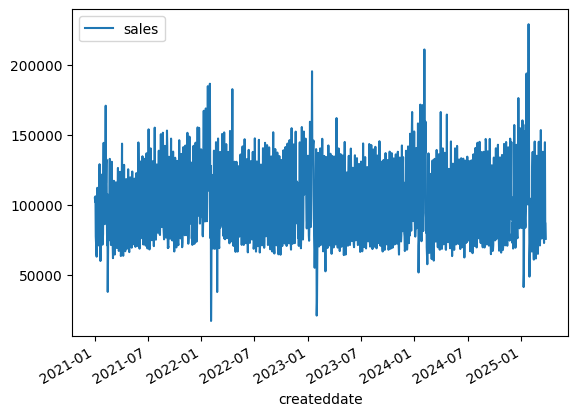

In [255]:
sql.plot()

In [256]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing,ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from scipy.stats import boxcox
%matplotlib inline


In [257]:
sql.head()

,sales
createddate,
2021-01-01,104545.67
2021-01-02,101959.89
2021-01-03,105851.80
2021-01-04,77273.75
2021-01-05,72252.07


In [258]:
y_transformed, fitted_lambda = boxcox(sql['sales'])
print(y_transformed,fitted_lambda)


[5.13740517 5.13372494 5.13922401 ... 5.11023162 5.10965139 5.08835315] -0.16610674492048902


In [259]:
sql['sales_transformed']=y_transformed

In [11]:
sql.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


<Axes: xlabel='createddate'>

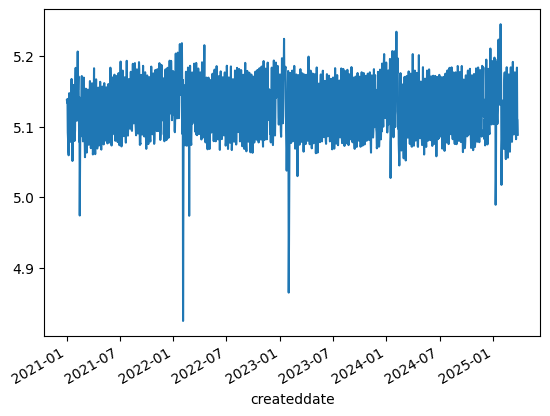

In [260]:
sql['sales_transformed'].plot()

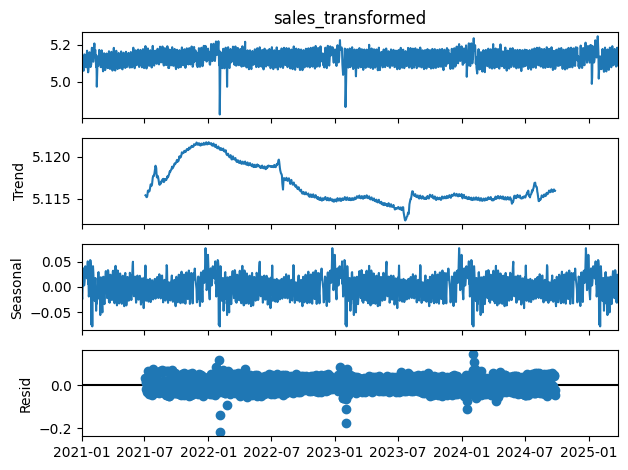

In [261]:
decompose_result=seasonal_decompose(sql['sales_transformed'],model='additive',period=365)
residuals=decompose_result.resid.dropna()
decompose_result.plot()
plt.show()

In [262]:
sql.tail()

,sales,sales_transformed
createddate,,
2025-03-22,109166.47,5.143725
2025-03-23,144519.80,5.183633
2025-03-24,87104.95,5.110232
2025-03-25,86771.34,5.109651
2025-03-26,75496.43,5.088353


In [263]:
sql=sql.asfreq('D').ffill()

In [264]:
sql.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1546 entries, 2021-01-01 to 2025-03-26
Freq: D
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sales              1546 non-null   float64
 1   sales_transformed  1546 non-null   float64
dtypes: float64(2)
memory usage: 36.2 KB


In [265]:
train,test=sql[:'2024-12-31'],sql['2025-01-01':]

In [266]:
train.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


In [267]:
model = ExponentialSmoothing(
    train['sales'],
    #trend='mul',
    seasonal='mul',
    seasonal_periods=365,
    initialization_method="estimated"
)

fit = model.fit(optimized=True)

C:\Users\lenovo\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


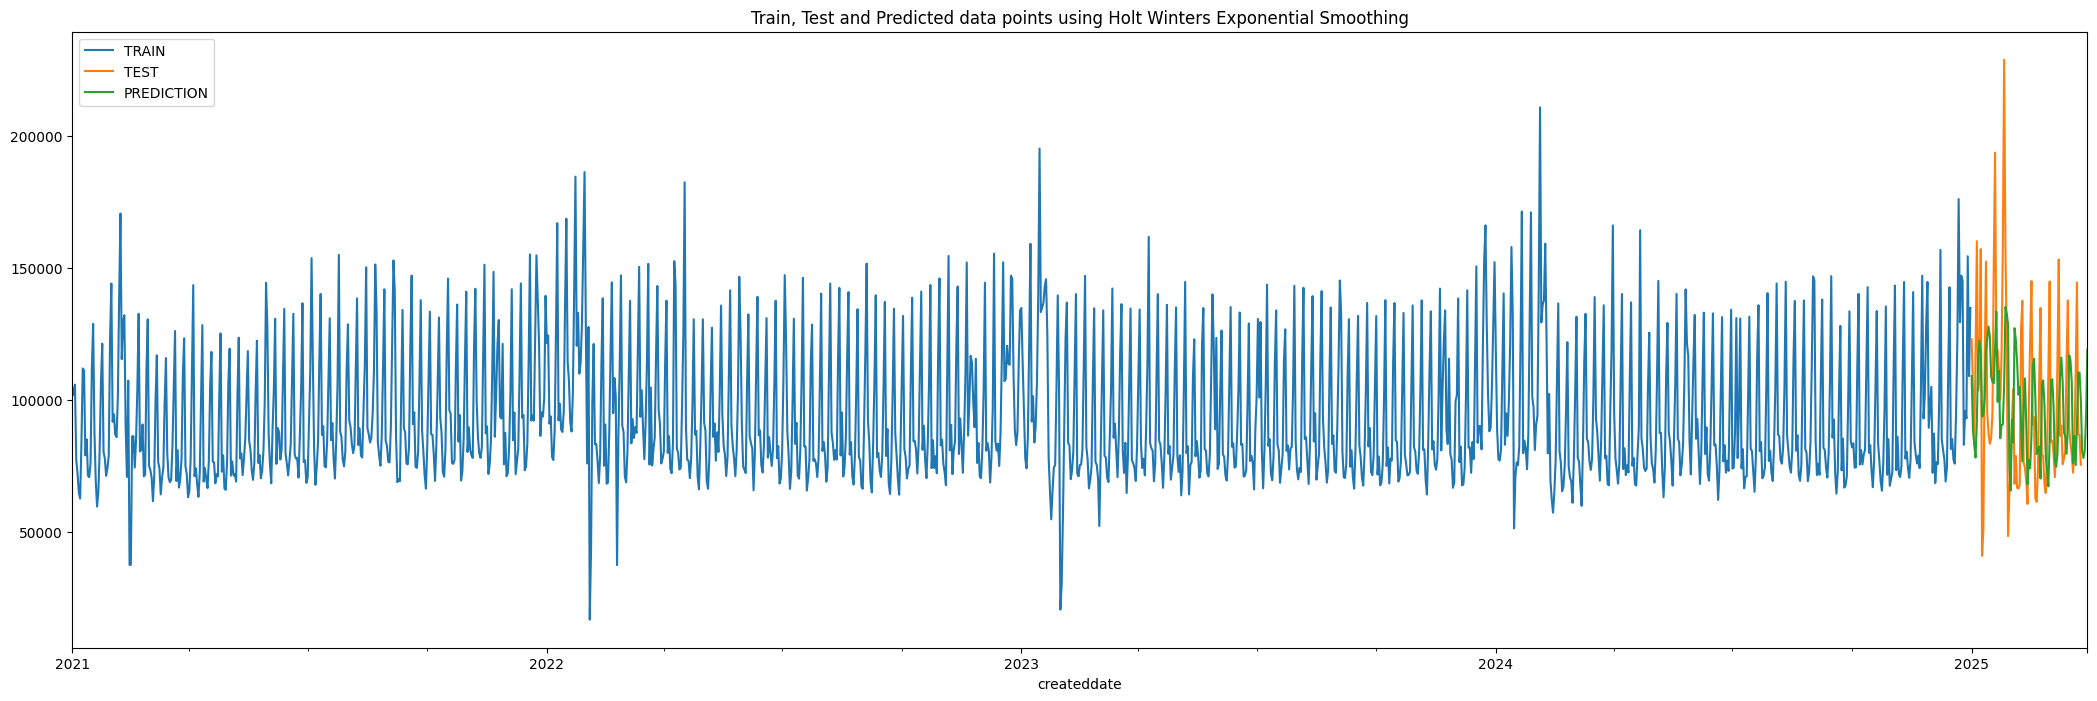

In [268]:
forecast=fit.forecast(90)
forecast_index = pd.date_range(start=test['sales'].index[0], periods=90,freq='D') 
test_predictions = pd.Series(forecast.values,index=forecast_index)

train['sales'].plot(legend=True,label='TRAIN',figsize=(26,8))
test['sales'].plot(legend=True,label='TEST',figsize=(26,8))
test_predictions.plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Holt Winters Exponential Smoothing')
plt.show()

In [269]:
model = ExponentialSmoothing(
    train['sales_transformed'],
    trend='add',
    seasonal='add',
    seasonal_periods=280,
    initialization_method="estimated"
)

fit = model.fit(optimized=True)

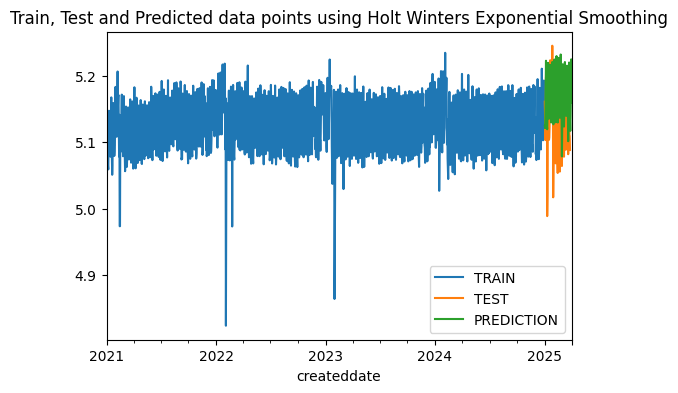

In [270]:
forecast=fit.forecast(90)
forecast_index = pd.date_range(start=test['sales_transformed'].index[0], periods=90,freq='D') 
test_predictions = pd.Series(forecast.values,index=forecast_index)

train['sales_transformed'].plot(legend=True,label='TRAIN')
test['sales_transformed'].plot(legend=True,label='TEST',figsize=(6,4))
test_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted data points using Holt Winters Exponential Smoothing')
plt.show()

In [406]:
train_df=pd.DataFrame(train['sales'])

In [407]:
train_df

,sales
createddate,
2021-01-01,104545.67
2021-01-02,101959.89
2021-01-03,105851.80
2021-01-04,77273.75
2021-01-05,72252.07
...,...
2024-12-27,95781.70
2024-12-28,93063.02
2024-12-29,154448.66


In [410]:
train_df.reset_index(inplace=True)

In [408]:
train_df.rename(columns={'createddate':'ds','sales':'y'},inplace=True)

In [411]:
train_df.head()

,createddate,y
0,2021-01-01,104545.67
1,2021-01-02,101959.89
2,2021-01-03,105851.80
3,2021-01-04,77273.75
4,2021-01-05,72252.07


In [276]:
from prophet import Prophet

model = Prophet(growth='flat',seasonality_mode='multiplicative',yearly_seasonality=True,daily_seasonality=True,changepoint_prior_scale=0.8)
model.fit(train_df)

# Make future dataframe
future = model.make_future_dataframe(periods=90, freq='D')  # forecast 12 months ahead

# Forecast
forecast1 = model.predict(future)

17:14:08 - cmdstanpy - INFO - Chain [1] start processing
17:14:08 - cmdstanpy - INFO - Chain [1] done processing


In [277]:
forecast1.set_index(keys='ds')['yhat']

ds
2021-01-01     98533.750321
2021-01-02    125065.614337
2021-01-03    152904.162300
2021-01-04     99896.212124
2021-01-05     98331.265732
                  ...      
2025-03-27     71713.379892
2025-03-28     79739.614856
2025-03-29    106758.371985
2025-03-30    135212.119624
2025-03-31     82929.036834
Name: yhat, Length: 1551, dtype: float64

<Axes: xlabel='ds'>

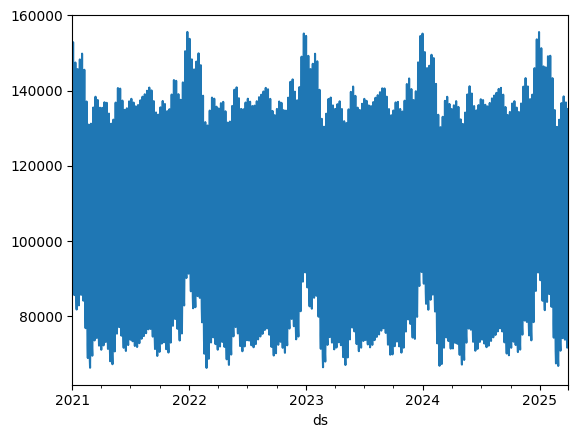

In [278]:
forecast1.set_index(keys='ds')['yhat'].plot()

In [309]:
train.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


In [308]:
test.head()

,ds,sales,sales_transformed
0,2025-01-01,123043.93,5.160975
1,2025-01-02,104379.69,5.137172
2,2025-01-03,83206.22,5.103284
3,2025-01-04,116833.69,5.153552
4,2025-01-05,160155.95,5.197787


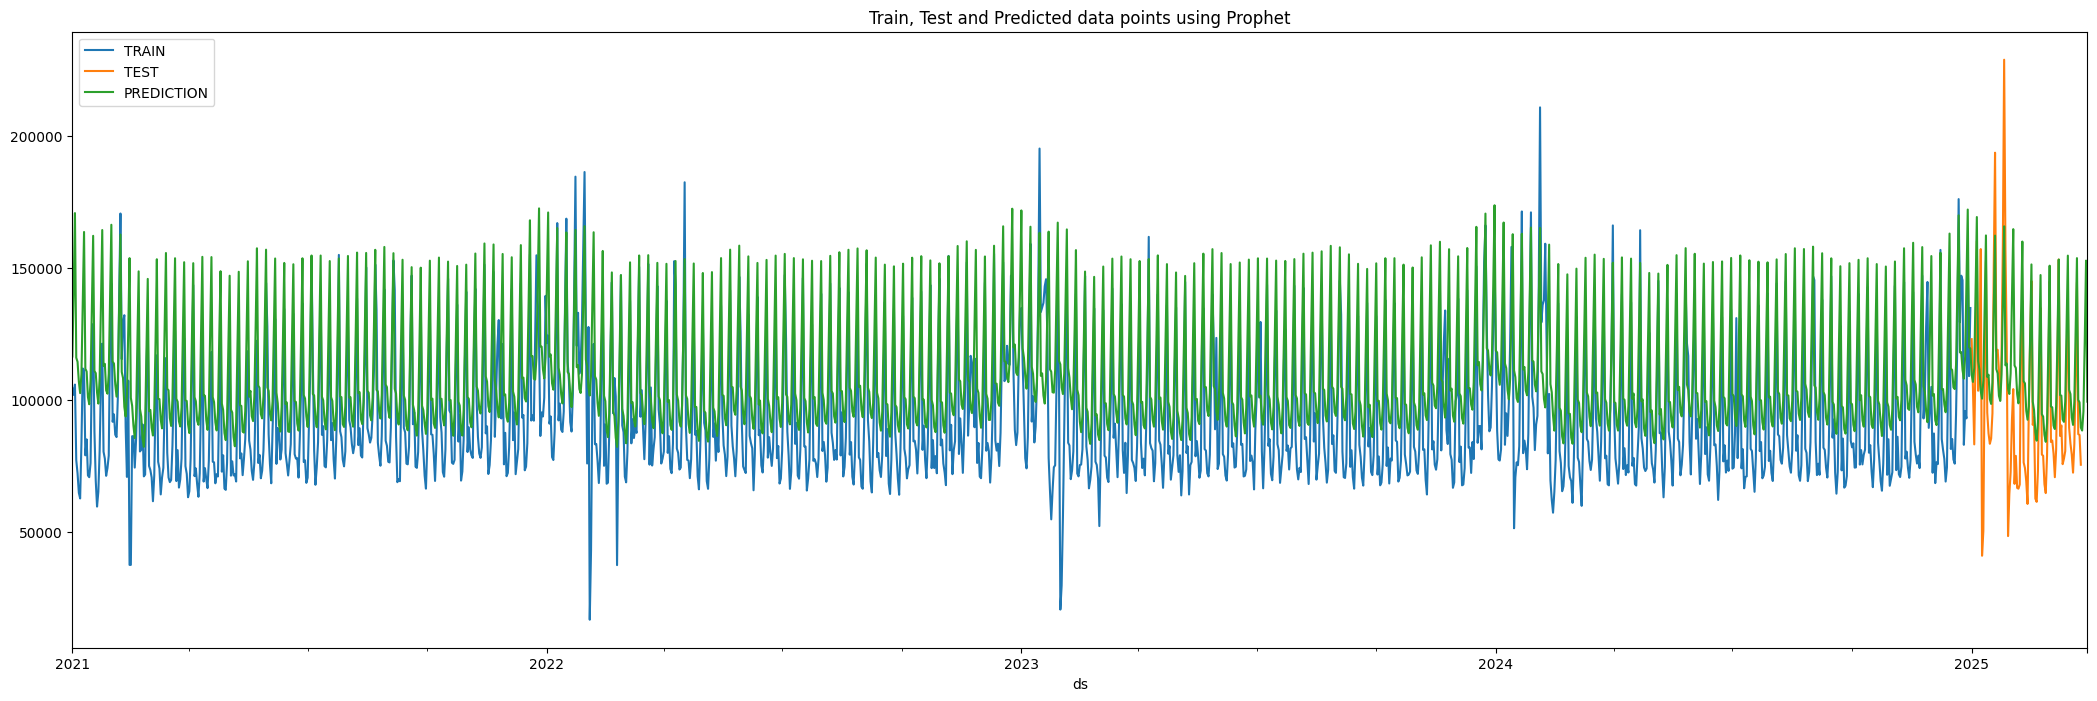

In [310]:
train['sales'].plot(legend=True,label='TRAIN',figsize=(26,8))
test.set_index('ds')['sales'].plot(legend=True,label='TEST',figsize=(26,8))
forecast1.set_index('ds')['yhat_upper'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()

In [284]:
forecast1.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,daily,daily_lower,daily_upper,multiplicative_terms,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2021-01-01,96469.839883,83199.999086,116489.754314,96469.839883,96469.839883,-0.026075,-0.026075,-0.026075,0.021394,...,-0.111508,-0.111508,-0.111508,0.158977,0.158977,0.158977,0.0,0.0,0.0,98533.750321
1,2021-01-02,96469.839883,108624.803886,140968.869236,96469.839883,96469.839883,-0.026075,-0.026075,-0.026075,0.296422,...,0.170283,0.170283,0.170283,0.152214,0.152214,0.152214,0.0,0.0,0.0,125065.614337
2,2021-01-03,96469.839883,136573.694769,170786.956628,96469.839883,96469.839883,-0.026075,-0.026075,-0.026075,0.584994,...,0.466396,0.466396,0.466396,0.144674,0.144674,0.144674,0.0,0.0,0.0,152904.162300
3,2021-01-04,96469.839883,82140.775219,116017.623435,96469.839883,96469.839883,-0.026075,-0.026075,-0.026075,0.035518,...,-0.074979,-0.074979,-0.074979,0.136572,0.136572,0.136572,0.0,0.0,0.0,99896.212124
4,2021-01-05,96469.839883,81736.320003,114484.337413,96469.839883,96469.839883,-0.026075,-0.026075,-0.026075,0.019295,...,-0.082767,-0.082767,-0.082767,0.128138,0.128138,0.128138,0.0,0.0,0.0,98331.265732


In [286]:
forecast1[['ds', 'yhat']]

,ds,yhat
0,2021-01-01,98533.750321
1,2021-01-02,125065.614337
2,2021-01-03,152904.162300
3,2021-01-04,99896.212124
4,2021-01-05,98331.265732
...,...,...
1546,2025-03-27,71713.379892
1547,2025-03-28,79739.614856
1548,2025-03-29,106758.371985
1549,2025-03-30,135212.119624


In [287]:
test.reset_index(inplace=True)

In [360]:
test.head()

,ds,sales,sales_transformed
0,2025-01-01,123043.93,5.160975
1,2025-01-02,104379.69,5.137172
2,2025-01-03,83206.22,5.103284
3,2025-01-04,116833.69,5.153552
4,2025-01-05,160155.95,5.197787


In [418]:
train_df.rename(columns={'createddate':'ds'},inplace=True)

In [291]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
merged = test.merge(forecast1[['ds', 'yhat']], on='ds')

# Calculate metrics
mae = mean_absolute_error(merged['sales'], merged['yhat'])
mse = mean_squared_error(merged['sales'], merged['yhat'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(merged['sales'], merged['yhat']) * 100

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 14164.707
RMSE: 21265.597
MAPE: 14.91%


In [419]:
train_df.head()

,ds,y
0,2021-01-01,104545.67
1,2021-01-02,101959.89
2,2021-01-03,105851.80
3,2021-01-04,77273.75
4,2021-01-05,72252.07


In [293]:
train_df[(train_df['y']<60000)]

,ds,y
19,2021-01-20,59652.01
44,2021-02-14,37570.65
45,2021-02-15,37570.65
398,2022-02-03,16809.36
399,2022-02-04,43209.73
419,2022-02-24,37487.71
753,2023-01-24,54822.13
760,2023-01-31,20650.08
761,2023-02-01,29816.24
762,2023-02-02,56012.42


In [89]:
test[(test['sales']<60000)]['sales']

createddate
2025-01-09    41035.07
2025-01-10    50415.88
2025-01-29    48492.95
Name: sales, dtype: float64

In [85]:
train_df[(train_df['y']>150000)]

,ds,y
37,2021-02-07,170634.43
184,2021-07-04,153751.79
205,2021-07-25,154958.08
226,2021-08-15,150261.66
233,2021-08-22,151338.06
247,2021-09-05,152860.55
317,2021-11-14,151261.25
352,2021-12-19,155148.93
357,2021-12-24,154804.35
373,2022-01-09,167006.28


In [103]:
train_df.head()

,ds,y
0,2021-01-01,104545.67
1,2021-01-02,101959.89
2,2021-01-03,105851.80
3,2021-01-04,77273.75
4,2021-01-05,72252.07


In [106]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2021-01-01 to 2024-12-31
Freq: D
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sales              1461 non-null   float64
 1   sales_transformed  1461 non-null   float64
dtypes: float64(2)
memory usage: 34.2 KB


In [206]:
sql2=pd.read_sql_query('''
select convert(date,convert(varchar(10),year(CONVERT(DATE, od.CreatedDate)))+'-'+convert(varchar(10),month((CONVERT(DATE, od.CreatedDate))))+'-'+'01') as 'CreatedDate',sum(finalPrice) as [Sales]
from [dbo].[tbl_OrderDetail] od 
where
OrderID
not in ('3211060','3165824','3212852','3372453','3385933','3482724','3482724','3586376','3563806','3515162','3530330','3543646','3548076','3547856','3522858','1312770','1291603','1288788','3372453','3385933','3334146','3282281','3287210','3211060','3165824','3097531','3077123','3021897','2980680','2966784','2969104','2941023','2904791','2860424','2803291','2776905','2793767','2791152',
'2683177','2614174','2611535','2493530','2449724','2463572','2362509','1741885','1468654','872847','795968','813638','1291603','1288788','3252697','3262309','3230367','3250698','3128813','3137846',
'3141462','3137720','3110348','2719266','2712391','2741312','2719826','2725825','2383949','1656709','1662110','1600042','1662110','1656709','1661634','1692835','1382092','1535400','1600042','1372042',
'1662110','1656709','1468654','1475580','1561131','1329726','1323058','1323611','1314264','1347803','1291603','1288788','1226161','1155445','1162913','1183928','1170695','1160134','1153447','1183268',
'1070359','1062859','3021897','2980680','2860424','2828823','1150807','1113390','1147945','930056','906565','904282','2803291','2793767','763380','744679','777017','739443','992541','1007888','1021529',
'995756','1006986','996203')
and year(CONVERT(DATE, od.CreatedDate)) between 2021 and 2025
group by convert(date,convert(varchar(10),year(CONVERT(DATE, od.CreatedDate)))+'-'+convert(varchar(10),month((CONVERT(DATE, od.CreatedDate))))+'-'+'01') 
order by convert(date,convert(varchar(10),year(CONVERT(DATE, od.CreatedDate)))+'-'+convert(varchar(10),month((CONVERT(DATE, od.CreatedDate))))+'-'+'01')
 ''',engine)

In [213]:
sql2.head()

,createddate,sales
0,2021-01-01,2760838.47
1,2021-02-01,2571772.19
2,2021-03-01,2554172.56
3,2021-04-01,2507022.44
4,2021-05-01,2786049.42


In [214]:
sql2['createddate']=pd.to_datetime(sql2['createddate'],format='%Y-%m-%d')
sql2.set_index('createddate',inplace=True)

In [216]:
sql2.tail()

,sales
createddate,
2024-11-01,2890376.35
2024-12-01,3187926.09
2025-01-01,3519576.66
2025-02-01,2451401.77
2025-03-01,2498217.47


<Axes: xlabel='createddate'>

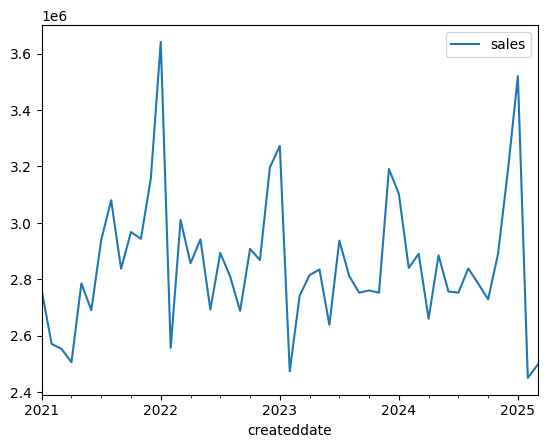

In [215]:
sql2.plot()

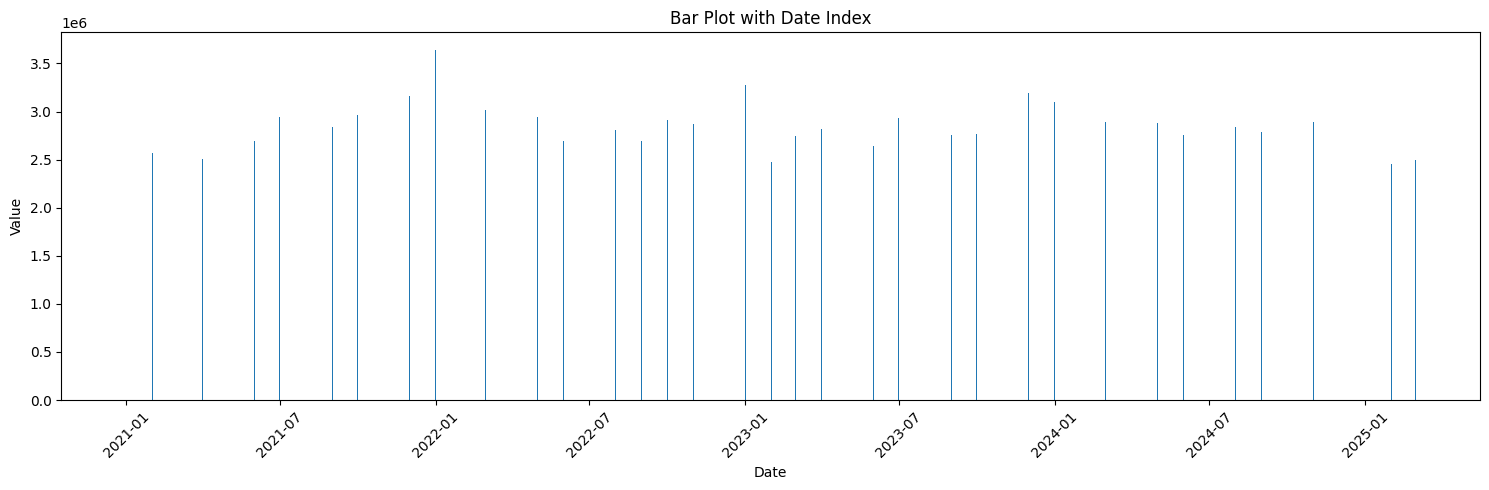

In [218]:
plt.figure(figsize=(15, 5))
plt.bar(sql2.index, sql2['sales'], width=0.8)  # width can be adjusted
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Bar Plot with Date Index')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [404]:
train_df['y']=train['sales']

In [412]:
train_df.head()

,createddate,y
0,2021-01-01,104545.67
1,2021-01-02,101959.89
2,2021-01-03,105851.80
3,2021-01-04,77273.75
4,2021-01-05,72252.07


In [228]:
train_df[train_df['festive']!=1]

,ds,y,festive,post_festive_dip
31,2021-02-01,91769.21,0,1
32,2021-02-02,94560.79,0,1
33,2021-02-03,86879.29,0,1
34,2021-02-04,85973.00,0,1
35,2021-02-05,101017.63,0,1
...,...,...,...,...
1425,2024-11-26,101955.42,0,0
1426,2024-11-27,127990.70,0,0
1427,2024-11-28,144711.52,0,0
1428,2024-11-29,89458.87,0,0


In [311]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ds                1461 non-null   datetime64[ns]
 1   y                 1461 non-null   float64       
 2   festive           1461 non-null   int32         
 3   post_festive_dip  1461 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 34.4 KB


In [414]:
train_df.tail()

,createddate,y
1456,2024-12-27,95781.70
1457,2024-12-28,93063.02
1458,2024-12-29,154448.66
1459,2024-12-30,109069.63
1460,2024-12-31,134850.79


In [420]:
# Festive boost: December and January
train_df['festive'] = train_df['ds'].dt.month.isin([12, 1]).astype(int)


In [421]:
train_df['festive']=train_df['festive']*1000000

In [437]:
model = Prophet(
    growth='flat',seasonality_mode='additive',yearly_seasonality=True,daily_seasonality=True,changepoint_prior_scale=0.8
)

# Add custom regressors
model.add_regressor('festive')

In [438]:
model

In [398]:
y_transformed,y_lambda=boxcox(train_df['y'])
train_df['y']=y_transformed

In [439]:
train_df.head()

,ds,y,festive
0,2021-01-01,104545.67,1000000
1,2021-01-02,101959.89,1000000
2,2021-01-03,105851.80,1000000
3,2021-01-04,77273.75,1000000
4,2021-01-05,72252.07,1000000


In [440]:
model.fit(train_df)

19:11:41 - cmdstanpy - INFO - Chain [1] start processing
19:11:41 - cmdstanpy - INFO - Chain [1] done processing


In [441]:
future = model.make_future_dataframe(periods=90, freq='D')

# Add the same features to future
future['festive'] = future['ds'].dt.month.isin([12, 1]).astype(int)
#future['post_festive_dip'] = (future['ds'].dt.month == 2).astype(int)

In [442]:
future['festive']=future['festive']*1000000

In [443]:
future.head()

,ds,festive
0,2021-01-01,1000000
1,2021-01-02,1000000
2,2021-01-03,1000000
3,2021-01-04,1000000
4,2021-01-05,1000000


In [444]:
forecast = model.predict(future)

In [445]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-01,93967.349625,81747.983605,115205.108931,93967.349625,93967.349625,4103.438707,4103.438707,4103.438707,-13.170815,...,-10748.259812,-10748.259812,-10748.259812,20244.063668,20244.063668,20244.063668,0.0,0.0,0.0,98070.788332
1,2021-01-02,93967.349625,109363.828590,141577.636869,93967.349625,93967.349625,30666.362161,30666.362161,30666.362161,-13.170815,...,16437.871915,16437.871915,16437.871915,19620.855396,19620.855396,19620.855396,0.0,0.0,0.0,124633.711787
2,2021-01-03,93967.349625,136914.291365,170663.997422,93967.349625,93967.349625,58587.216893,58587.216893,58587.216893,-13.170815,...,45036.795044,45036.795044,45036.795044,18942.786997,18942.786997,18942.786997,0.0,0.0,0.0,152554.566518
3,2021-01-04,93967.349625,83060.843601,116259.153196,93967.349625,93967.349625,5612.592489,5612.592489,5612.592489,-13.170815,...,-7224.179412,-7224.179412,-7224.179412,18229.137050,18229.137050,18229.137050,0.0,0.0,0.0,99579.942114
4,2021-01-05,93967.349625,81212.709742,114090.470662,93967.349625,93967.349625,4100.519438,4100.519438,4100.519438,-13.170815,...,-8006.515261,-8006.515261,-8006.515261,17499.399848,17499.399848,17499.399848,0.0,0.0,0.0,98067.869063


<Axes: xlabel='ds'>

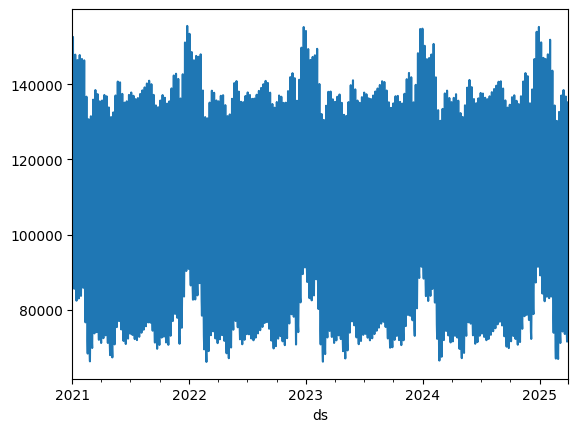

In [446]:
forecast.set_index('ds')['yhat'].plot()

In [448]:
model.params['beta']  

array([[-3.06939e-03,  2.87737e-02,  2.82869e-03,  2.80006e-02,
         8.29282e-04,  1.97356e-02,  6.44212e-04,  7.98534e-03,
         8.61289e-03,  6.94023e-03,  2.13857e-03, -1.14031e-03,
        -5.26621e-03, -2.31538e-03, -1.44104e-03,  2.10990e-03,
        -9.72187e-03,  6.57271e-04, -8.49860e-03,  5.96415e-03,
         6.90924e-02, -9.74934e-02, -6.21833e-02,  4.08436e-03,
         4.65154e-02,  3.17837e-03,  1.34082e-13, -1.56182e-05,
         2.68165e-13, -1.56182e-05,  4.42577e-12, -1.56182e-05,
         5.36329e-13, -1.56182e-05, -1.15409e-02]])

In [386]:
train_df.isna().sum()

ds         0
y          0
festive    0
dtype: int64

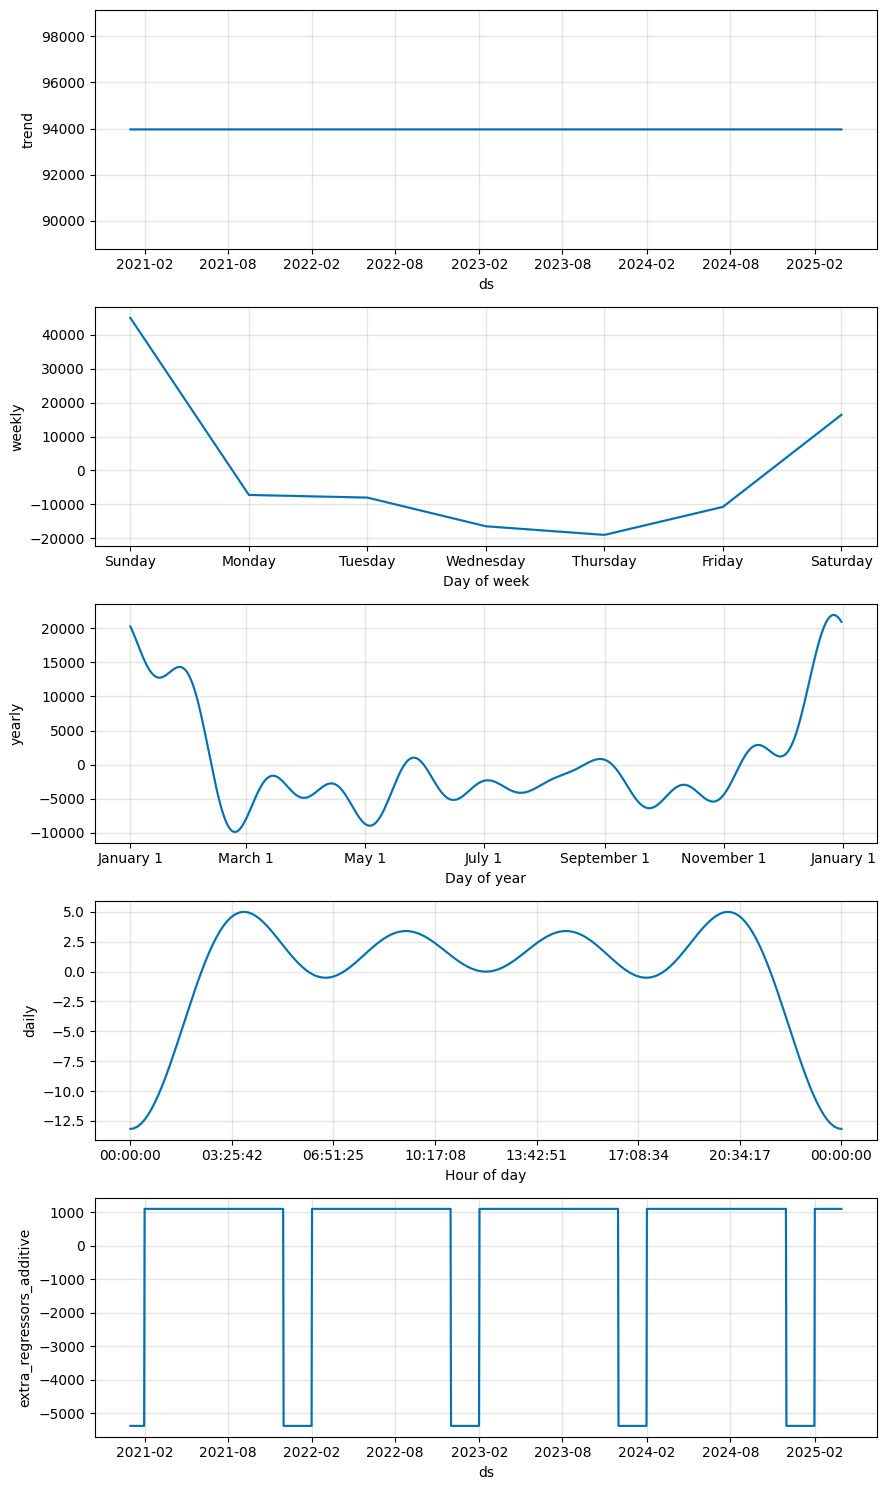

In [449]:
model.plot_components(forecast)
plt.show()

In [388]:
train_df.tail()

,ds,y,festive
1456,2024-12-27,95781.70,100000
1457,2024-12-28,93063.02,100000
1458,2024-12-29,154448.66,100000
1459,2024-12-30,109069.63,100000
1460,2024-12-31,134850.79,100000


In [389]:
test.tail()

,ds,sales,sales_transformed
80,2025-03-22,109166.47,5.143725
81,2025-03-23,144519.80,5.183633
82,2025-03-24,87104.95,5.110232
83,2025-03-25,86771.34,5.109651
84,2025-03-26,75496.43,5.088353


In [390]:
forecast.set_index('ds')['yhat'].tail(10)

ds
2025-03-22    108434.877698
2025-03-23    136713.623958
2025-03-24     84140.630759
2025-03-25     83065.833970
2025-03-26     74336.846373
2025-03-27     71562.786921
2025-03-28     79659.032294
2025-03-29    106717.676725
2025-03-30    135243.117656
2025-03-31     82963.688944
Name: yhat, dtype: float64

In [346]:
sql.head()

,sales,sales_transformed
createddate,,
2021-01-01,104545.67,5.137405
2021-01-02,101959.89,5.133725
2021-01-03,105851.80,5.139224
2021-01-04,77273.75,5.091948
2021-01-05,72252.07,5.081529


In [347]:
sql.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1546 entries, 2021-01-01 to 2025-03-26
Freq: D
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sales              1546 non-null   float64
 1   sales_transformed  1546 non-null   float64
dtypes: float64(2)
memory usage: 68.5 KB


In [349]:
sql.to_csv('daily_dallas.csv')

In [350]:
sql2.head()

,sales
createddate,
2021-01-01,2760838.47
2021-02-01,2571772.19
2021-03-01,2554172.56
2021-04-01,2507022.44
2021-05-01,2786049.42


In [351]:
sql2.to_csv('daily_dallas_1.csv')

In [393]:
test.head()

,ds,sales,sales_transformed
0,2025-01-01,123043.93,5.160975
1,2025-01-02,104379.69,5.137172
2,2025-01-03,83206.22,5.103284
3,2025-01-04,116833.69,5.153552
4,2025-01-05,160155.95,5.197787


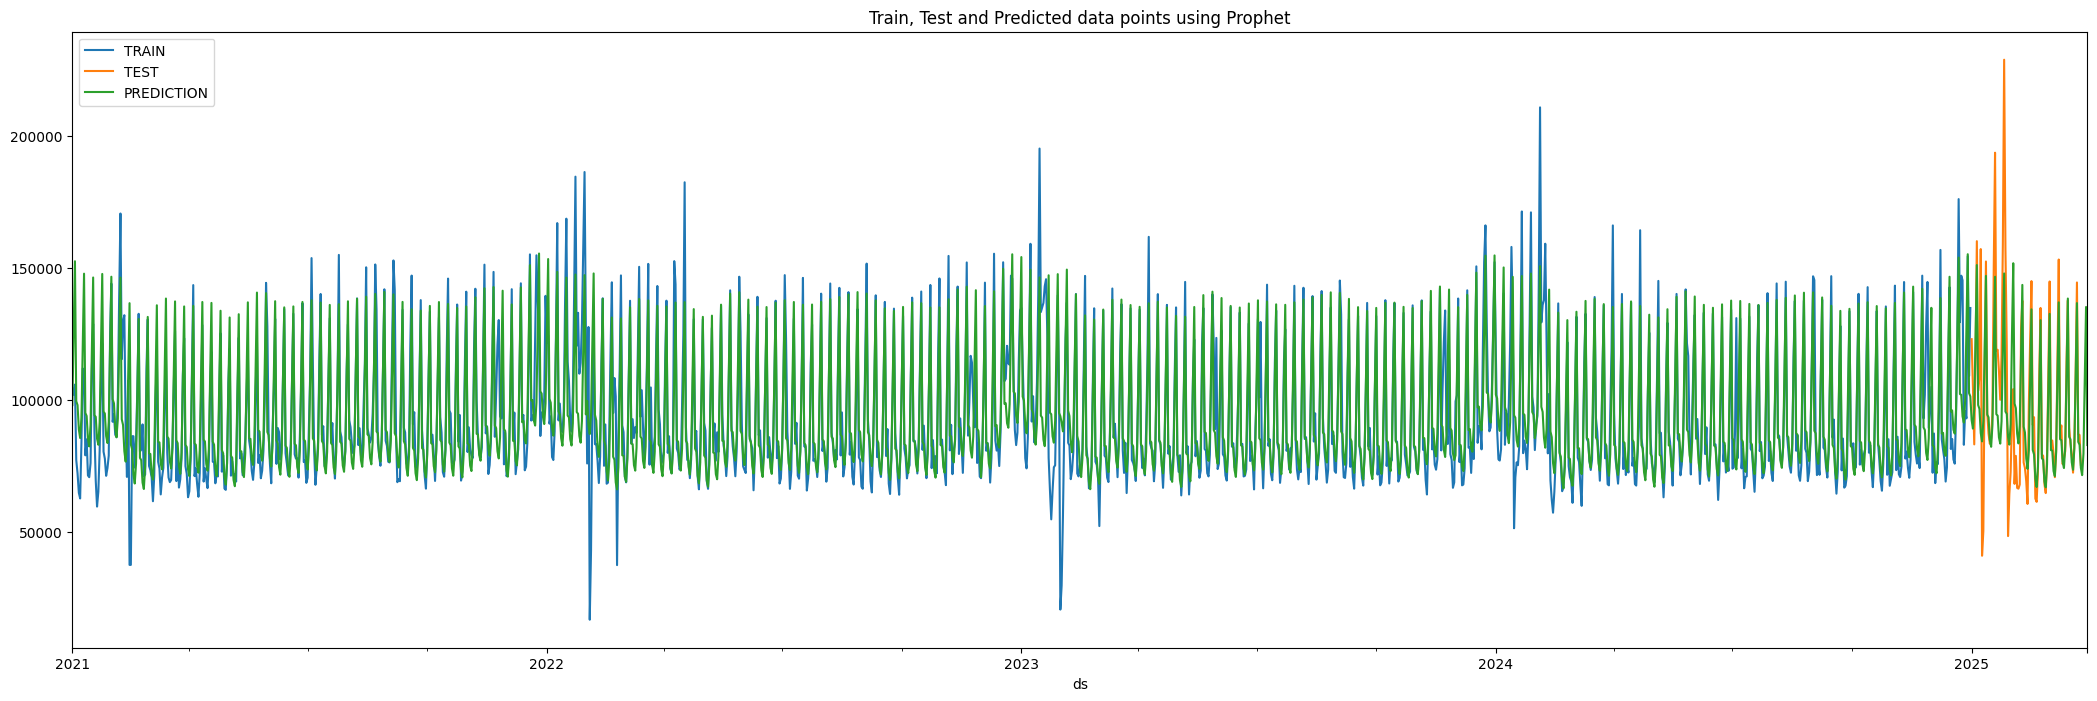

In [450]:
train_df.set_index('ds')['y'].plot(legend=True,label='TRAIN',figsize=(26,8))
test.set_index('ds')['sales'].plot(legend=True,label='TEST',figsize=(26,8))
#forecast1.set_index('ds')['yhat'].plot(legend=True,label='PREDICTION1',figsize=(26,8))
forecast.set_index('ds')['yhat'].plot(legend=True,label='PREDICTION',figsize=(26,8))
plt.title('Train, Test and Predicted data points using Prophet')
plt.show()

In [392]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
merged = test.merge(forecast[['ds', 'yhat']], on='ds')

# Calculate metrics
mae = mean_absolute_error(merged['sales'], merged['yhat'])
mse = mean_squared_error(merged['sales'], merged['yhat'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(merged['sales'], merged['yhat']) * 100

print(f'MAE: {mae:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAPE: {mape:.2f}%')

MAE: 13743.376
RMSE: 20544.292
MAPE: 15.11%
